In [2]:
import sys
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/data/')
from make_dataset import *
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/models/')
from train_model import *
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

0.8


In [ ]:
interim_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/interim/'
processed_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/processed/'

In [3]:
preprocessed_data = load_data(interim_filepath, file_name='dataset.pkl')

processed_data = load_data(processed_filepath, file_name='features.pkl')

dataset = pd.merge(preprocessed_data, processed_data, on='match_id')

dataset.describe()

,WRank,LRank,B365W,B365L,match_id,RankP1,RankP2,Surface_Carpet,Surface_Clay,Surface_Grass,Surface_Hard,OddP1,OddP2,H2H,Y_B365,winner_is_p1,Rank_dif,Odd_dif
count,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000
mean,56.975444,90.815012,1.810274,3.534008,19260.113668,43.577328,90.125251,0.032340,0.316139,0.112278,0.539243,1.390174,3.696084,0.326208,0.678425,0.703166,-57.920062,-2.305910
std,71.749121,113.711153,1.091412,3.426320,9990.255185,42.930227,63.329665,0.176904,0.464975,0.315713,0.498465,0.223505,2.086364,1.267710,0.111162,0.456870,119.343701,2.275397
min,1.000000,1.000000,1.000000,1.002000,1371.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.830000,-10.000000,0.147059,0.000000,-1778.000000,-9.000000
25%,16.000000,35.000000,1.222000,1.720000,10697.500000,13.000000,45.000000,0.000000,0.000000,0.000000,0.000000,1.200000,2.250000,0.000000,0.589005,0.000000,-74.000000,-3.130000
50%,40.000000,65.000000,1.500000,2.500000,19393.000000,31.000000,75.000000,0.000000,0.000000,0.000000,1.000000,1.390000,2.870000,0.000000,0.662651,1.000000,-35.000000,-1.490000
75%,75.000000,104.000000,2.000000,4.000000,27902.500000,61.000000,115.000000,0.000000,1.000000,0.000000,1.000000,1.570000,4.330000,1.000000,0.766284,1.000000,-10.000000,-0.680000
max,1821.000000,1855.000000,29.000000,67.000000,36362.000000,250.000000,250.000000,1.000000,1.000000,1.000000,1.000000,1.909000,10.000000,16.000000,0.906618,1.000000,1059.000000,0.000000


In [4]:
dataset_classified = load_data(processed_filepath, file_name='features_classified.pkl')
dataset_classified.describe()

,match_id,Surface_Carpet,Surface_Clay,Surface_Grass,Surface_Hard,H2H,Y_B365,winner_is_p1,RankP1_classified,RankP2_classified,Rank_dif_classified,OddP1_classified,OddP2_classified,Odd_dif_classified
count,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000
mean,19260.113668,0.032340,0.316139,0.112278,0.539243,0.326208,0.678425,0.703166,11.839104,11.923367,11.941189,6.722069,6.764695,6.806857
std,9990.255185,0.176904,0.464975,0.315713,0.498465,1.267710,0.111162,0.456870,7.302810,7.236406,7.196580,4.308726,4.409008,4.295666
min,1371.000000,0.000000,0.000000,0.000000,0.000000,-10.000000,0.147059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10697.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589005,0.000000,6.000000,6.000000,6.000000,3.000000,3.000000,3.000000
50%,19393.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.662651,1.000000,12.000000,12.000000,12.000000,7.000000,7.000000,7.000000
75%,27902.500000,0.000000,1.000000,0.000000,1.000000,1.000000,0.766284,1.000000,18.000000,18.000000,18.000000,10.000000,11.000000,11.000000
max,36362.000000,1.000000,1.000000,1.000000,1.000000,16.000000,0.906618,1.000000,24.000000,24.000000,24.000000,14.000000,14.000000,14.000000


In [5]:
def create_multiple_histograms(data_list, bins=10, colors=None, labels=None, xlabel="X-axis", ylabel="Frequency", printValues=True):
    """
    Create multiple histograms on the same plot.

    Parameters:
    - data_list: List of lists, each containing numerical data for a histogram.
    - bins: Number of bins for the histograms (default is 10).
    - colors: List of colors for each histogram (optional).
    - labels: List of labels for each histogram (optional).
    - title: Title of the histogram (default is "Histogram").
    - xlabel: Label for the X-axis (default is "X-axis").
    - ylabel: Label for the Y-axis (default is "Frequency").

    Returns:
    - None (displays the histograms using Matplotlib).
    """
    # Plot each histogram
    for i, data in enumerate(data_list):
        # Create the histogram using numpy
        counts, bin_edges = np.histogram(data, bins=bins)
    
        if printValues==True:
            # Display a table of histogram values
            print(f"Histogram Values of {labels[i]}:")
            print(f"{'Bin Edges':<15}{'Count':<10}")
            for edge, count in zip(bin_edges, counts):
                print(f"{edge:<15.2f}{count:<10}")
        
        plt.hist(data, bins=bins, edgecolor='black', color=colors[i] if colors else None, label=labels[i] if labels else None, alpha=0.7)

    # Set plot labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Add legend if labels are provided
    if labels:
        plt.legend()

    # Show the plot
    plt.show()


Winner
Loser
WRank


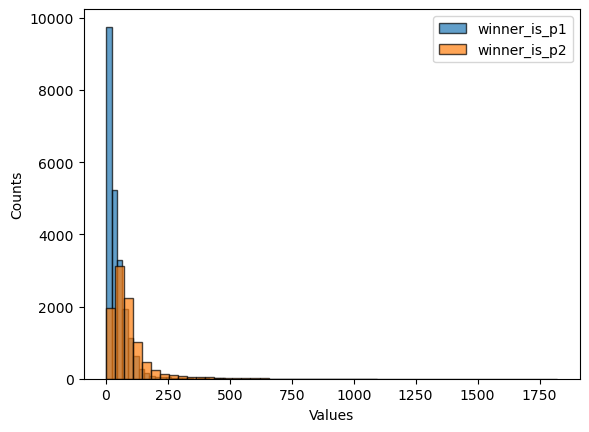

LRank


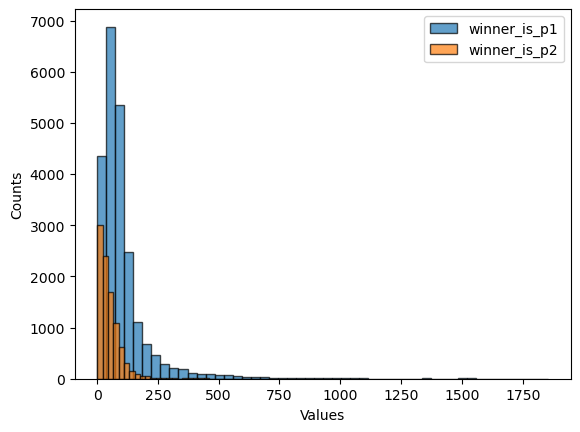

B365W


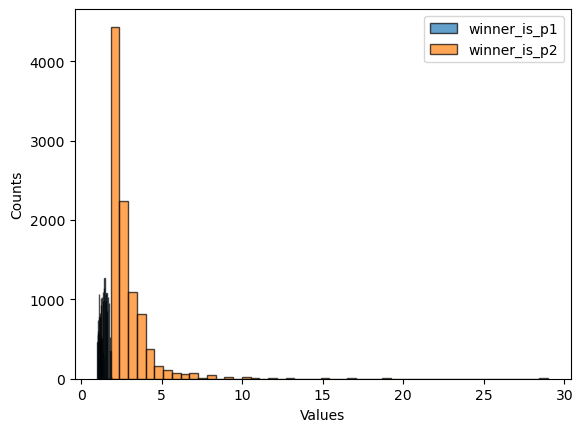

B365L


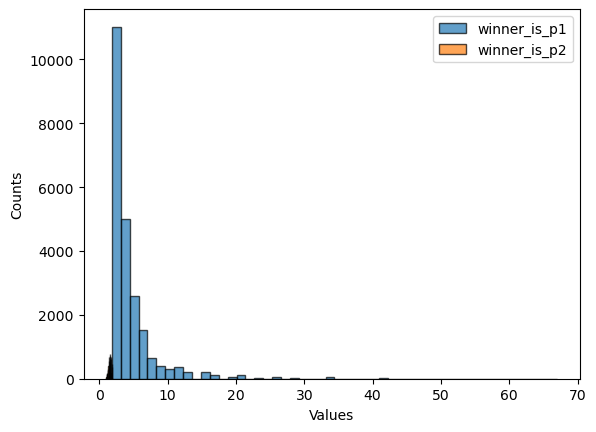

Surface
RankP1


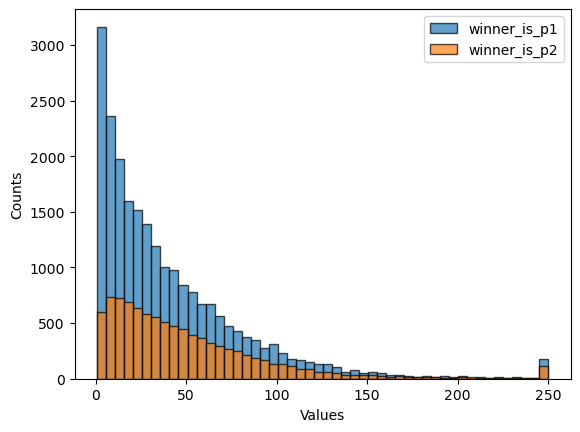

RankP2


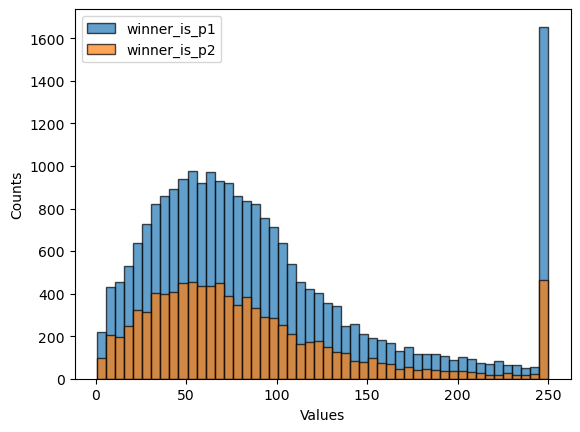

Surface_Carpet


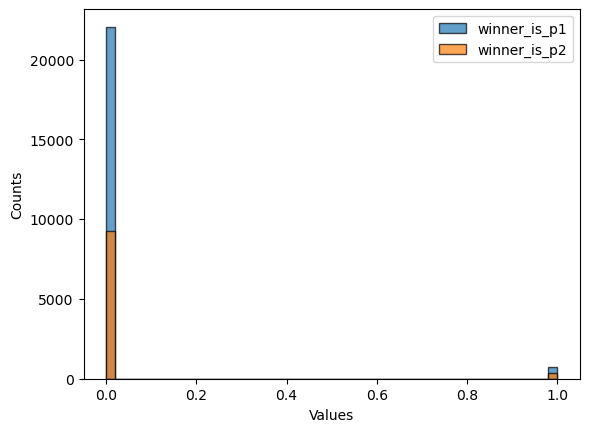

Surface_Clay


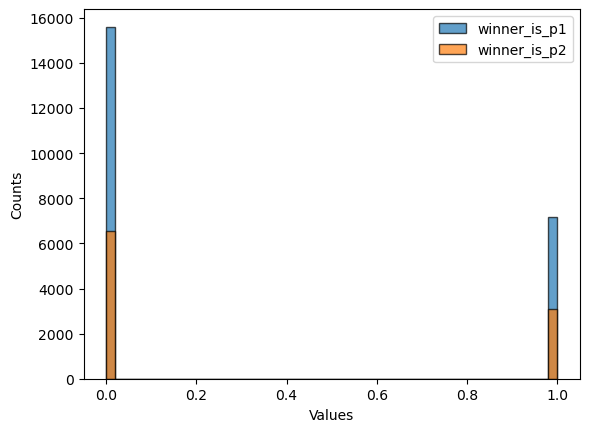

Surface_Grass


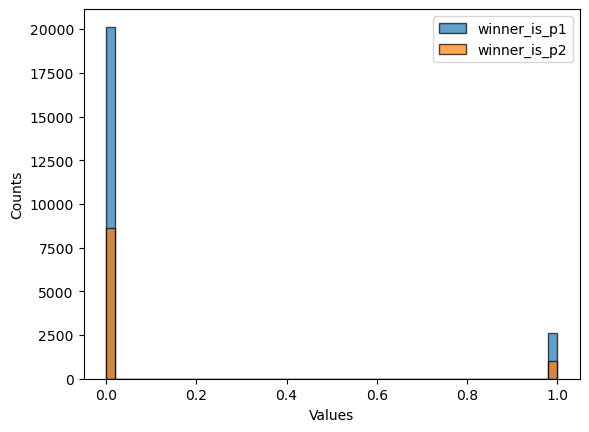

Surface_Hard


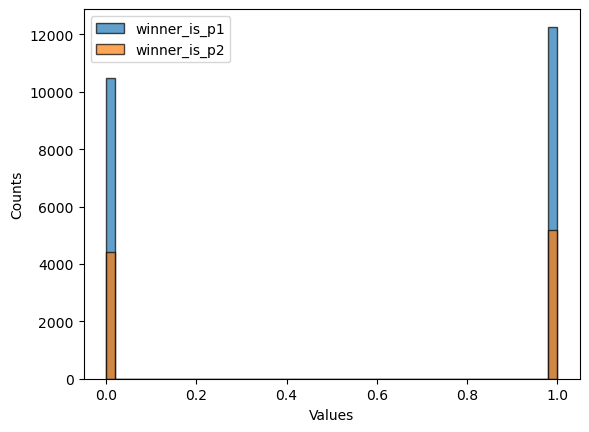

OddP1


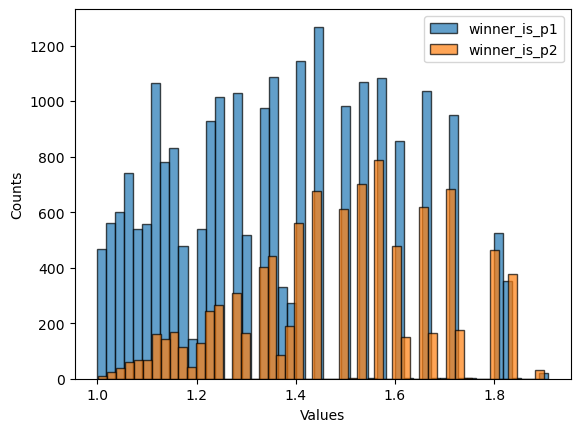

OddP2


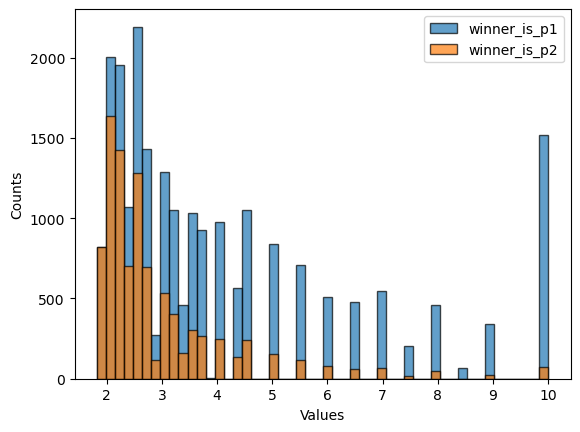

H2H


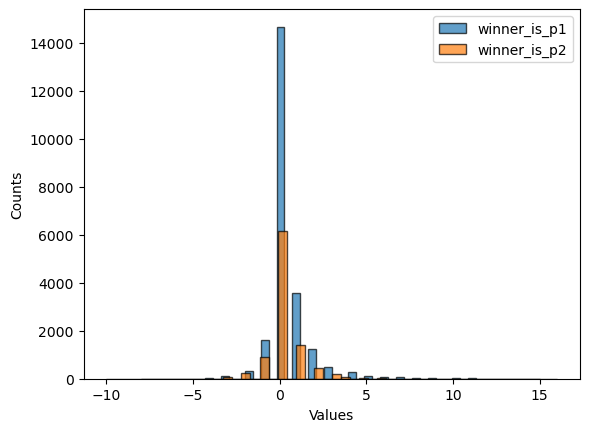

Y_B365


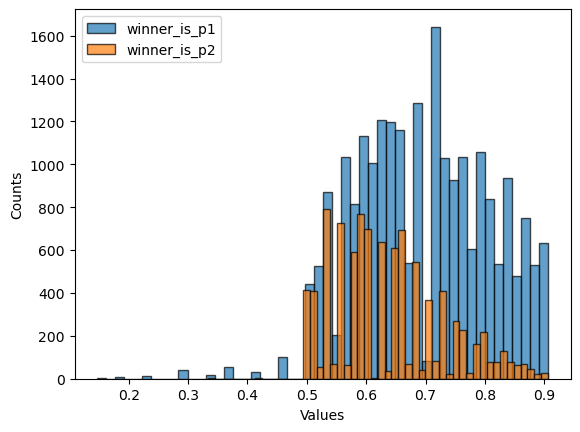

winner_is_p1


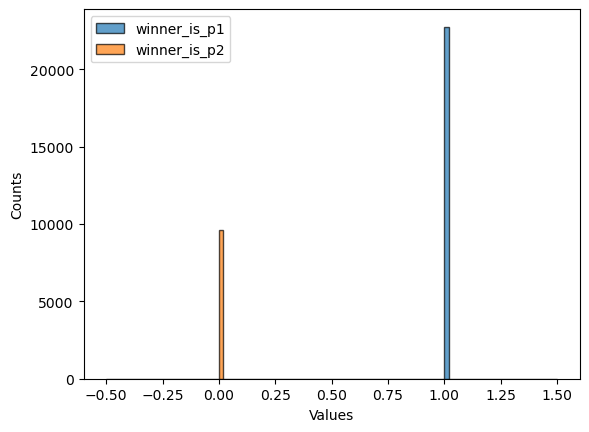

Rank_dif


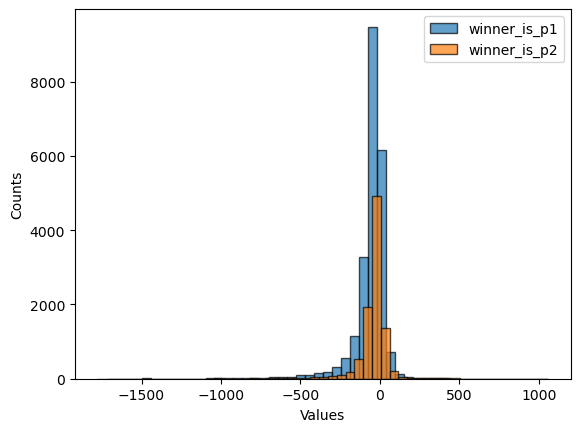

Odd_dif


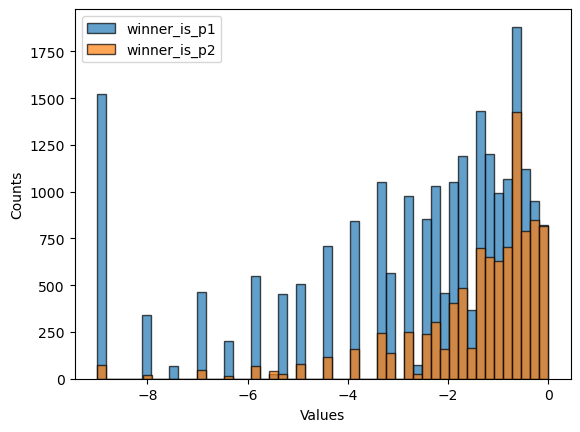

In [6]:
for col in dataset.columns:
    if col == 'match_id':
        pass
    else:
        print(col)
        data1 = [dataset[col][dataset['winner_is_p1'] == 1]]
        data2 = [dataset[col][dataset['winner_is_p1'] == 0]]
        try:
            create_multiple_histograms([data1,data2], bins=50, labels=['winner_is_p1','winner_is_p2'], xlabel="Values", ylabel="Counts", printValues=False)
        except:
            pass

Surface_Carpet


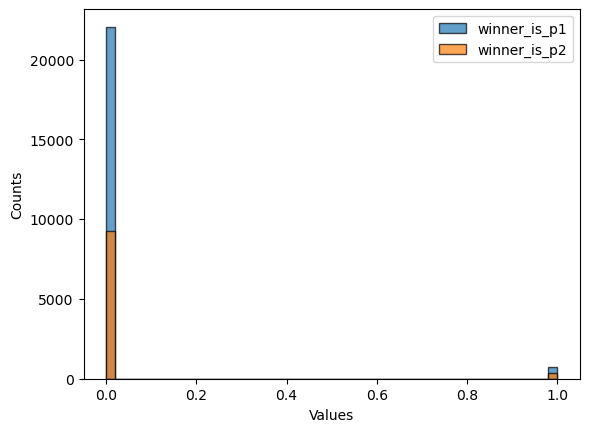

Surface_Clay


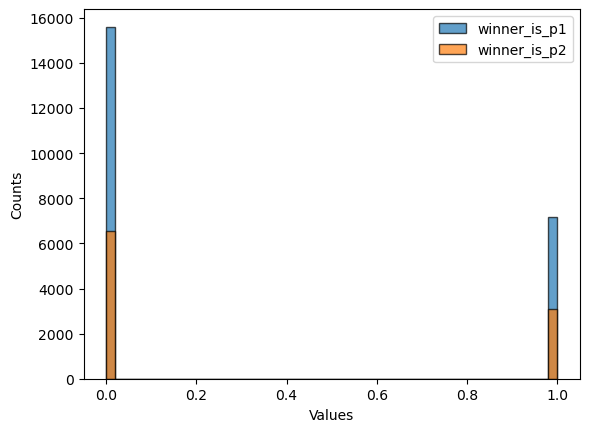

Surface_Grass


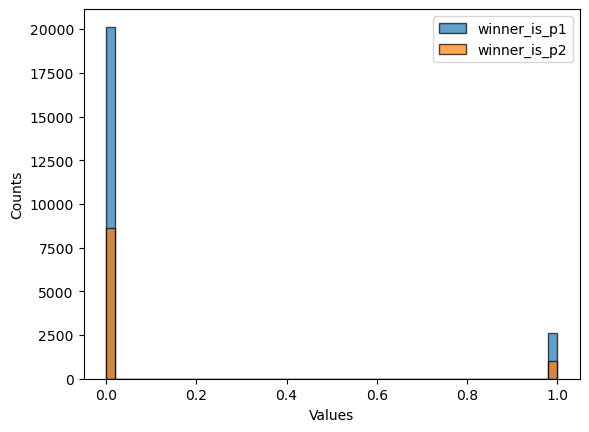

Surface_Hard


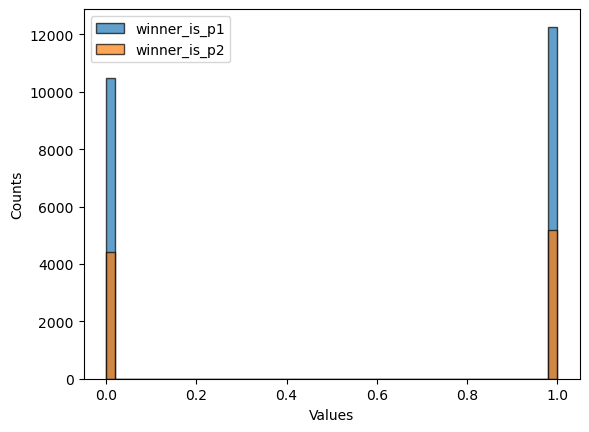

H2H


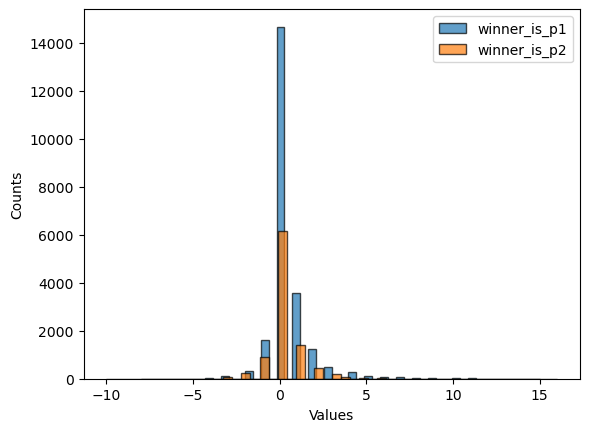

Y_B365


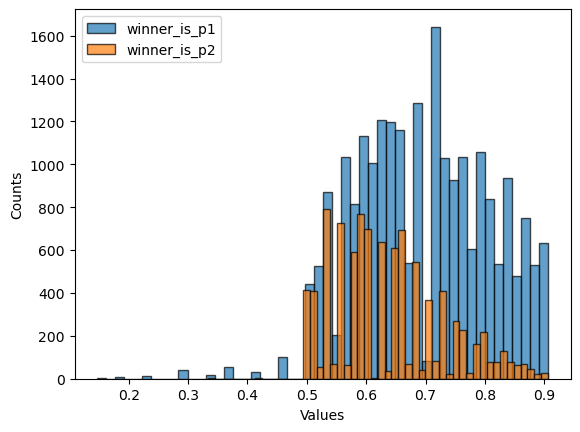

winner_is_p1


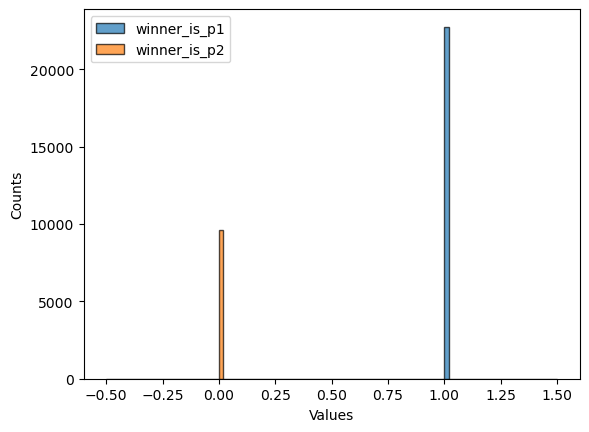

RankP1_classified


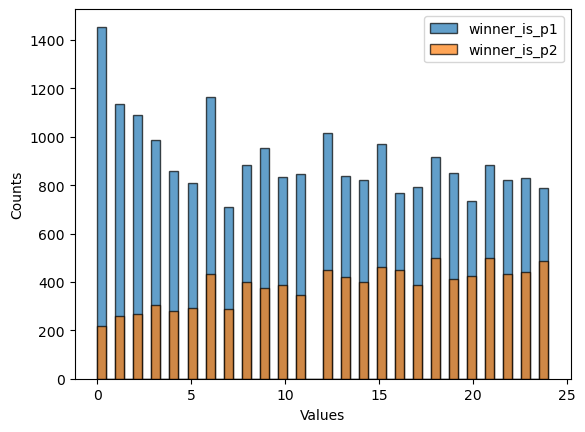

RankP2_classified


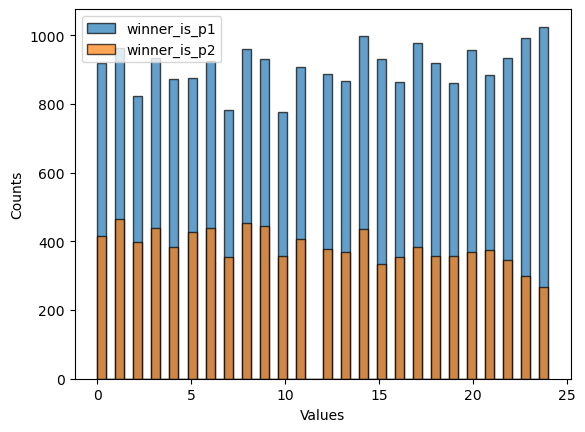

Rank_dif_classified


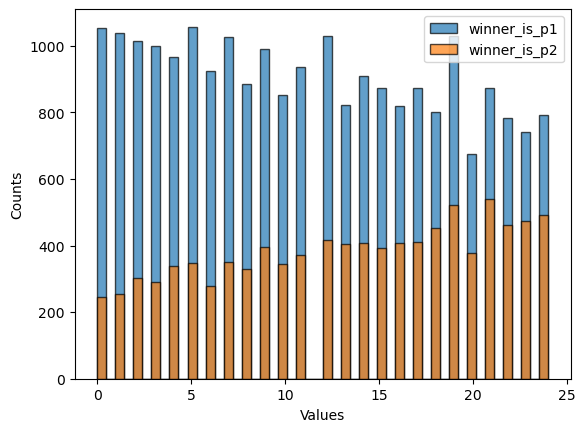

OddP1_classified


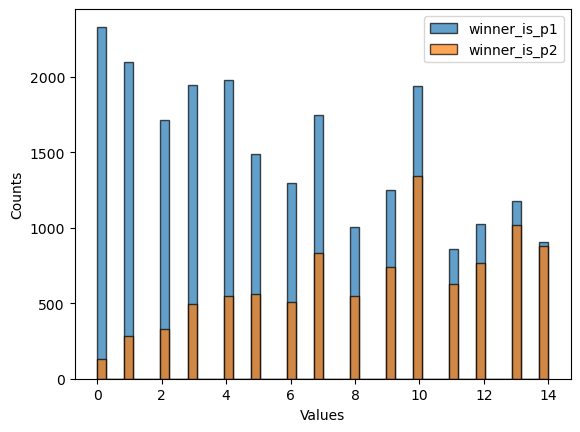

OddP2_classified


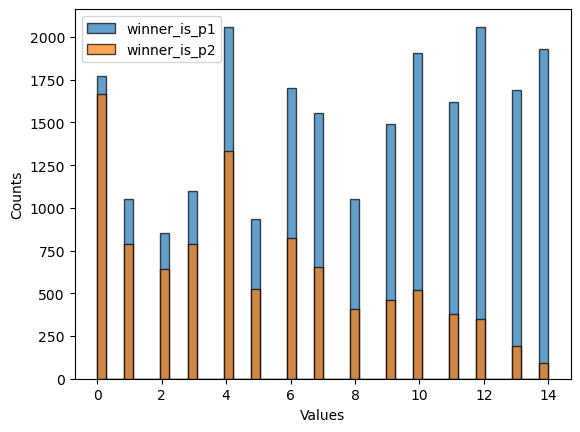

Odd_dif_classified


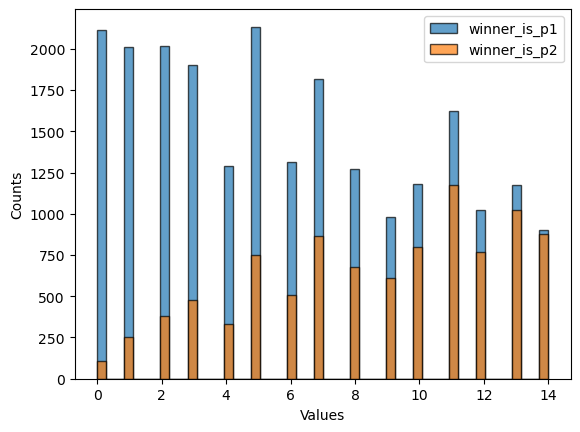

In [7]:
for col in dataset_classified.columns:
    if col == 'match_id':
        pass
    else:
        print(col)
        data1 = [dataset_classified[col][dataset_classified['winner_is_p1'] == 1]]
        data2 = [dataset_classified[col][dataset_classified['winner_is_p1'] == 0]]
        create_multiple_histograms([data1,data2], bins=50, labels=['winner_is_p1','winner_is_p2'], xlabel="Values", ylabel="Counts", printValues=False)

In [ ]:
odds = dataset[['OddP1_classified', 'OddP2_classified', 'winner_is_p1']]
sns.pairplot(odds, hue='winner_is_p1')

In [ ]:
rank = dataset[['Rank_dif_classified', 'winner_is_p1']]
sns.pairplot(rank, hue='winner_is_p1')

There are no correlated features.


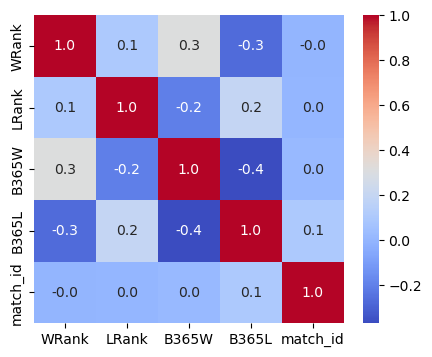

In [8]:
# Identify numeric columns
numeric_columns = preprocessed_data.select_dtypes(include='number').columns

# Create a correlation matrix for numeric columns
correlation_matrix = preprocessed_data[numeric_columns].corr()

threshold = 0.7

# Display column names where correlation exceeds the threshold
high_correlation_columns = (correlation_matrix.abs() > threshold) & (correlation_matrix != 1)
correlated_columns = high_correlation_columns.unstack().reset_index()
correlated_columns = correlated_columns[correlated_columns[0]].rename_axis(None, axis=1)
if correlated_columns.empty:
    print('There are no correlated features.')
else:
    print("Column pairs with correlation above", threshold)
    print(correlated_columns)

# Config figure size
plt.figure(figsize=(5,4))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f")

# Display the plot
plt.show()

Columns sorted by correlation with winner_is_p1
Index(['winner_is_p1', 'OddP1', 'Odd_dif', 'OddP2', 'Y_B365', 'RankP1',
       'Rank_dif', 'H2H', 'RankP2', 'Surface_Grass', 'match_id',
       'Surface_Carpet', 'Surface_Clay', 'Surface_Hard'],
      dtype='object')
Column pairs with correlation above 0.7
          level_0       level_1     0
62   Surface_Clay  Surface_Hard  True
88   Surface_Hard  Surface_Clay  True
106         OddP1         OddP2  True
108         OddP1        Y_B365  True
111         OddP1       Odd_dif  True
119         OddP2         OddP1  True
125         OddP2       Odd_dif  True
147        Y_B365         OddP1  True
189       Odd_dif         OddP1  True
190       Odd_dif         OddP2  True


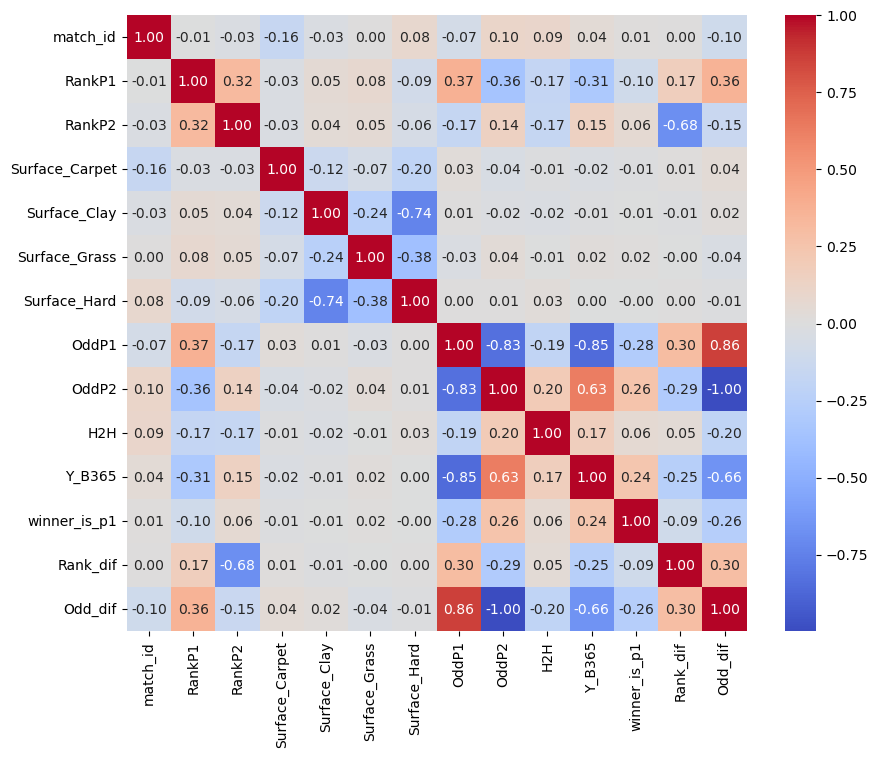

In [13]:
# Identify numeric columns
numeric_columns = processed_data.select_dtypes(include='number').columns

# Create a correlation matrix for numeric columns
correlation_matrix = processed_data[numeric_columns].corr()

# Print the columns sorted by their correlation with target_column
# Set the target column for sorting
target_column = 'winner_is_p1'

# Sort columns based on correlation with the target column
sorted_columns = correlation_matrix[target_column].abs().sort_values(ascending=False).index

# Print sorted columns
print("Columns sorted by correlation with", target_column)
print(sorted_columns)

# Check if there are correlated features
threshold = 0.7

# Display column names where correlation exceeds the threshold
high_correlation_columns = (correlation_matrix.abs() > threshold) & (correlation_matrix != 1)
correlated_columns = high_correlation_columns.unstack().reset_index()
correlated_columns = correlated_columns[correlated_columns[0]].rename_axis(None, axis=1)
if correlated_columns.empty:
    print('There are no correlated features.')
else:
    print("Column pairs with correlation above", threshold)
    print(correlated_columns)


# Display correlation matrix
# Config figure size
plt.figure(figsize=(10,8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Save figure
plt.savefig("C:/Users/inesm/projectos/tennis-predictor/reports/figures/correlation-matrix.png")

# Display the plot
plt.show()

To avoid working with correlated features must choose between:

1. Surface_Carpet, Surface_Clay, Surface_Grass and Surface_Hard
2. OddP1, OddP2, Odd_dif and YB365

The most correlated features with the target are:
1. Surface_Grass (0.02)
2. OddP1 (-0.28)